In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#نتاكد انه قرا الفايلات نخليه يطبع اسمائهم
import os
folders = os.listdir('/content/drive/MyDrive/dataset')
print(folders)


['dyed-lifted-polyps', 'dyed-resection-margins', 'normal-pylorus', 'polyps', 'esophagitis', 'normal-cecum', 'normal-z-line', 'ulcerative-colitis']


Image count per class:
dyed-lifted-polyps: 1001
dyed-resection-margins: 1000
normal-pylorus: 1000
polyps: 1007
esophagitis: 1000
normal-cecum: 1000
normal-z-line: 1000
ulcerative-colitis: 1000


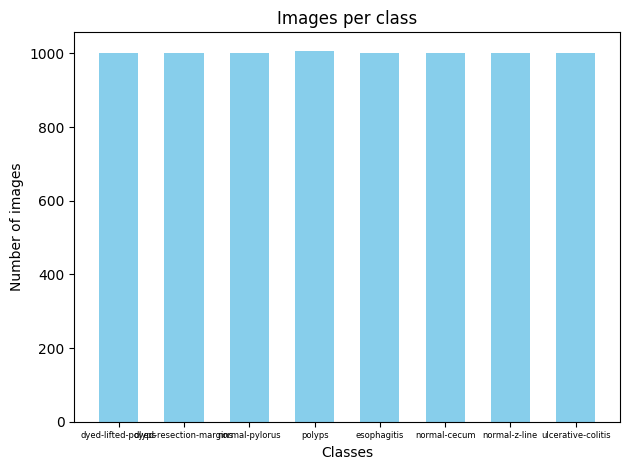

Dataset is relatively balanced ✅


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

# مسار الداتا سيت
dataset_path = '/content/drive/MyDrive/dataset'  # غيريه للمسار بتاعك

# جلب أسماء الفئات
classes = os.listdir(dataset_path)
image_count = {}

# عد الصور في كل كلاس
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
    image_count[cls] = count

# عرض النتيجة
print("Image count per class:")
for cls, count in image_count.items():
    print(f"{cls}: {count}")

# إعداد البار شارت
classes = list(image_count.keys())
counts = list(image_count.values())

x = np.arange(len(classes)) * 2  # زيادة المسافة بين الأعمدة
bar_width = 1.2  # عرض البار

plt.bar(x, counts, width=bar_width, color='skyblue')
plt.xlabel("Classes")
plt.ylabel("Number of images")
plt.title("Images per class")
plt.xticks(x, classes, fontsize=6)  # تصغير النص
plt.tight_layout()
plt.show()

# التحقق من التوازن
counts_list = list(image_count.values())
if max(counts_list) - min(counts_list) <= 0.1 * max(counts_list):
    print("Dataset is relatively balanced ✅")
else:
    print("Dataset is imbalanced ⚠️")


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

original_path = '/content/drive/MyDrive/dataset'
processed_path = '/content/drive/MyDrive/dataset_processedR'
os.makedirs(processed_path, exist_ok=True)


def preprocess_image(img, img_size=(224,224)):
    # Convert BGR to RGB
    if len(img.shape) == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, img_size)

    # Normalize
    img = img / 255.0

    return img

# معالجة كل الصور وحفظها

for cls in os.listdir(original_path):
    cls_folder = os.path.join(original_path, cls)
    if not os.path.isdir(cls_folder):
        continue

    save_folder = os.path.join(processed_path, cls)
    os.makedirs(save_folder, exist_ok=True)

    print(f"[INFO] Processing class: {cls}")
    for img_name in tqdm(os.listdir(cls_folder)):
        img_path = os.path.join(cls_folder, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        processed_img = preprocess_image(img)
        # حفظ الصورة
        save_path = os.path.join(save_folder, img_name)
        cv2.imwrite(save_path, cv2.cvtColor((processed_img*255).astype(np.uint8), cv2.COLOR_RGB2BGR))

print("✅ Preprocessing completed. All images saved.")


[INFO] Processing class: dyed-lifted-polyps


100%|██████████| 1001/1001 [01:03<00:00, 15.78it/s]


[INFO] Processing class: dyed-resection-margins


100%|██████████| 1000/1000 [00:44<00:00, 22.68it/s]


[INFO] Processing class: normal-pylorus


...

[INFO] Processing class: normal-z-line


100%|██████████| 1000/1000 [00:56<00:00, 17.62it/s]


[INFO] Processing class: ulcerative-colitis


100%|██████████| 1000/1000 [00:41<00:00, 23.98it/s]

✅ Preprocessing completed. All images saved.


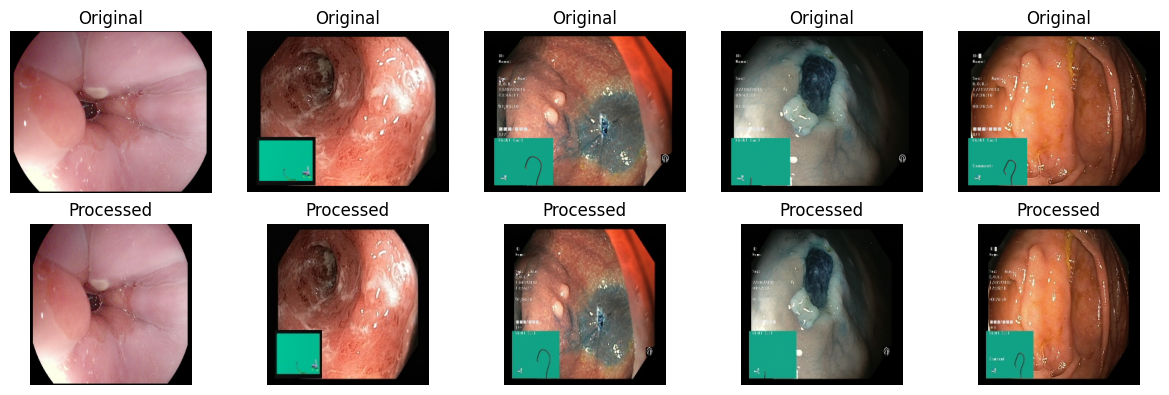

In [ ]:
import matplotlib.pyplot as plt
import random

def show_random_images(original_path, processed_path, n=5):
    classes = [c for c in os.listdir(original_path) if os.path.isdir(os.path.join(original_path,c))]
    plt.figure(figsize=(12,4))
    for i in range(n):
        cls = random.choice(classes)
        img_name = random.choice(os.listdir(os.path.join(original_path, cls)))

        orig_img = cv2.imread(os.path.join(original_path, cls, img_name))
        proc_img = cv2.imread(os.path.join(processed_path, cls, img_name))

        # Original
        plt.subplot(2,n,i+1)
        plt.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis('off')

        # Processed
        plt.subplot(2,n,i+1+n)
        plt.imshow(cv2.cvtColor(proc_img, cv2.COLOR_BGR2RGB))
        plt.title("Processed")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# تجربة العرض
show_random_images(original_path, processed_path, n=5)


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import shutil
from sklearn.model_selection import train_test_split

processed_path = '/content/drive/MyDrive/dataset_processedR'
split_path = '/content/drive/MyDrive/dataset_splitR'
os.makedirs(split_path, exist_ok=True)

splits = ['train', 'val', 'test']
for split in splits:
    os.makedirs(os.path.join(split_path, split), exist_ok=True)

for cls in os.listdir(processed_path):
    cls_folder = os.path.join(processed_path, cls)
    if not os.path.isdir(cls_folder):
        continue

    imgs = os.listdir(cls_folder)

    train_imgs, temp_imgs = train_test_split(imgs, test_size=0.2, random_state=42)

    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    for split_name, split_imgs in zip(splits, [train_imgs, val_imgs, test_imgs]):
        split_cls_folder = os.path.join(split_path, split_name, cls)
        os.makedirs(split_cls_folder, exist_ok=True)

        for img_name in split_imgs:
            src = os.path.join(cls_folder, img_name)
            dst = os.path.join(split_cls_folder, img_name)
            shutil.copy(src, dst)

print("✅ Data splitting completed: Train 80%, Val 10%, Test 10%")


In [ ]:
import shutil

# لو الفولدر موجود امسحيه علشان مايحصلش conflict
shutil.rmtree('/content/dataset_splitR', ignore_errors=True)

# انسخي الفولدر من Drive → الرام
shutil.copytree('/content/drive/MyDrive/dataset_splitR', '/content/dataset_splitR')

print("Dataset copied to RAM ✔️")


Dataset copied to RAM ✔️


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_path = '/content/dataset_splitR'
img_size = (224,224)
batch_size = 32


train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8,1.2],
    zoom_range=0.1
)

train_generator = train_datagen.flow_from_directory(
    directory=f'{base_path}/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)


val_datagen = ImageDataGenerator()
val_generator = val_datagen.flow_from_directory(
    directory=f'{base_path}/val',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_datagen = ImageDataGenerator()
test_generator = test_datagen.flow_from_directory(
    directory=f'{base_path}/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 7646 images belonging to 8 classes.
Found 1761 images belonging to 8 classes.
Found 1724 images belonging to 8 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf


base_model = ResNet50V2(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-15:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)      # مهمة جدًا
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

num_classes = len(train_generator.class_indices)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/best_ResNet50V2_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

csv_logger = CSVLogger(
    '/content/drive/MyDrive/training_log.csv',
    append=True      # مهم جدًا عشان يكمل على القديم
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[checkpoint, lr_reduce, csv_logger]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.4014 - loss: 1.6129
Epoch 1: val_accuracy improved from -inf to 0.50767, saving model to /content/drive/MyDrive/best_ResNet50V2_model.h5


239/239 ━━━━━━━━━━━━━━━━━━━━ 154s 562ms/step - accuracy: 0.4017 - loss: 1.6117 - val_accuracy: 0.5077 - val_loss: 1.4765 - learning_rate: 1.0000e-04
Epoch 2/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.5600 - loss: 1.0678
Epoch 2: val_accuracy improved from 0.50767 to 0.54742, saving model to /content/drive/MyDrive/best_ResNet50V2_model.h5


239/239 ━━━━━━━━━━━━━━━━━━━━ 123s 514ms/step - accuracy: 0.5600 - loss: 1.0678 - val_accuracy: 0.5474 - val_loss: 1.1853 - learning_rate: 1.0000e-04
Epoch 3/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.5933 - loss: 0.9709
Epoch 3: val_accuracy improved from 0.54742 to 0.57467, saving model to /content/drive/MyDrive/best_ResNet50V2_model.h5


239/239 ━━━━━━━━━━━━━━━━━━━━ 123s 515ms/step - accuracy: 0.5934 - loss: 0.9709 - val_accuracy: 0.5747 - val_loss: 1.0796 - learning_rate: 1.0000e-04
Epoch 4/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.6377 - loss: 0.8738
Epoch 4: val_accuracy did not improve from 0.57467
239/239 ━━━━━━━━━━━━━━━━━━━━ 119s 500ms/step - accuracy: 0.6377 - loss: 0.8737 - val_accuracy: 0.5292 - val_loss: 1.2521 - learning_rate: 1.0000e-04
Epoch 5/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.6586 - loss: 0.8080
Epoch 5: val_accuracy did not improve from 0.57467
239/239 ━━━━━━━━━━━━━━━━━━━━ 116s 486ms/step - accuracy: 0.6586 - loss: 0.8080 - val_accuracy: 0.4804 - val_loss: 1.7203 - learning_rate: 1.0000e-04
Epoch 6/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.6755 - loss: 0.7674
Epoch 6: val_accuracy did not improve from 0.57467

Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
239/239 ━━━━━━━━━━━━━━━━━━━━ 116s 484ms/step - accuracy: 0

239/239 ━━━━━━━━━━━━━━━━━━━━ 121s 508ms/step - accuracy: 0.6908 - loss: 0.7269 - val_accuracy: 0.7206 - val_loss: 0.6400 - learning_rate: 2.0000e-05
Epoch 8/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.7134 - loss: 0.6739
Epoch 8: val_accuracy did not improve from 0.72061
239/239 ━━━━━━━━━━━━━━━━━━━━ 119s 499ms/step - accuracy: 0.7134 - loss: 0.6739 - val_accuracy: 0.7047 - val_loss: 0.6890 - learning_rate: 2.0000e-05
Epoch 9/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.7106 - loss: 0.6806
Epoch 9: val_accuracy did not improve from 0.72061
239/239 ━━━━━━━━━━━━━━━━━━━━ 116s 485ms/step - accuracy: 0.7106 - loss: 0.6805 - val_accuracy: 0.7058 - val_loss: 0.6748 - learning_rate: 2.0000e-05
Epoch 10/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.7182 - loss: 0.6595
Epoch 10: val_accuracy did not improve from 0.72061

Epoch 10: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
239/239 ━━━━━━━━━━━━━━━━━━━━ 116s 486ms/step - accuracy:

239/239 ━━━━━━━━━━━━━━━━━━━━ 118s 494ms/step - accuracy: 0.7324 - loss: 0.6252 - val_accuracy: 0.7212 - val_loss: 0.6279 - learning_rate: 4.0000e-06
Epoch 14/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.7222 - loss: 0.6394
Epoch 14: val_accuracy improved from 0.72118 to 0.73424, saving model to /content/drive/MyDrive/best_ResNet50V2_model.h5


239/239 ━━━━━━━━━━━━━━━━━━━━ 122s 509ms/step - accuracy: 0.7222 - loss: 0.6394 - val_accuracy: 0.7342 - val_loss: 0.5966 - learning_rate: 4.0000e-06
Epoch 15/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.7462 - loss: 0.6284
Epoch 15: val_accuracy did not improve from 0.73424
239/239 ━━━━━━━━━━━━━━━━━━━━ 118s 495ms/step - accuracy: 0.7462 - loss: 0.6284 - val_accuracy: 0.7252 - val_loss: 0.6118 - learning_rate: 4.0000e-06
Epoch 16/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.7252 - loss: 0.6582
Epoch 16: val_accuracy did not improve from 0.73424
239/239 ━━━━━━━━━━━━━━━━━━━━ 115s 481ms/step - accuracy: 0.7252 - loss: 0.6581 - val_accuracy: 0.7280 - val_loss: 0.6040 - learning_rate: 4.0000e-06
Epoch 17/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.7177 - loss: 0.6304
Epoch 17: val_accuracy did not improve from 0.73424

Epoch 17: ReduceLROnPlateau reducing learning rate to 7.999999979801942e-07.
239/239 ━━━━━━━━━━━━━━━━━━━━ 117s 489ms/step - accur

In [ ]:
initial_epochs = 50

additional_epochs = 30

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=initial_epochs + additional_epochs,
    initial_epoch=initial_epochs,
    callbacks=[checkpoint, lr_reduce, csv_logger]
)

NameError: name 'model' is not defined

In [ ]:

final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]

print(f"✅ Final Train Accuracy: {final_train_acc*100:.2f}%")
print(f"✅ Final Validation Accuracy: {final_val_acc*100:.2f}%")

✅ Final Train Accuracy: 73.67%
✅ Final Validation Accuracy: 73.03%


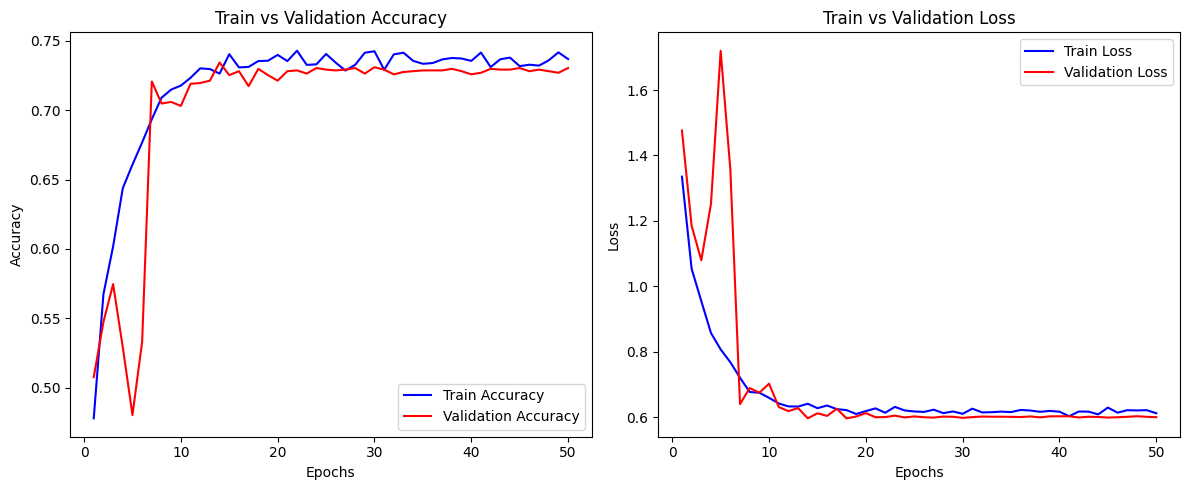

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b', label='Train Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Train vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b', label='Train Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Train vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"✅ Test Accuracy: {test_accuracy*100:.2f}%")
import numpy as np

# توقعات الموديل
y_pred = model.predict(test_generator)

# الكلاس المتوقع
y_pred_classes = np.argmax(y_pred, axis=1)

# الكلاس الحقيقي
y_true = test_generator.classes

# أسماء الكلاسات
class_names = list(test_generator.class_indices.keys())


54/54 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - accuracy: 0.7208 - loss: 0.5958
✅ Test Accuracy: 75.17%
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 133ms/step


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred_classes, target_names=class_names)
print(report)


                        precision    recall  f1-score   support

    dyed-lifted-polyps       0.68      0.58      0.63       250
dyed-resection-margins       0.68      0.84      0.75       252
           esophagitis       0.75      0.71      0.73       185
          normal-cecum       0.79      0.91      0.85       194
        normal-pylorus       0.84      0.99      0.91       194
         normal-z-line       0.75      0.66      0.70       180
                polyps       0.82      0.63      0.71       272
    ulcerative-colitis       0.73      0.75      0.74       197

              accuracy                           0.75      1724
             macro avg       0.75      0.76      0.75      1724
          weighted avg       0.75      0.75      0.75      1724



54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step


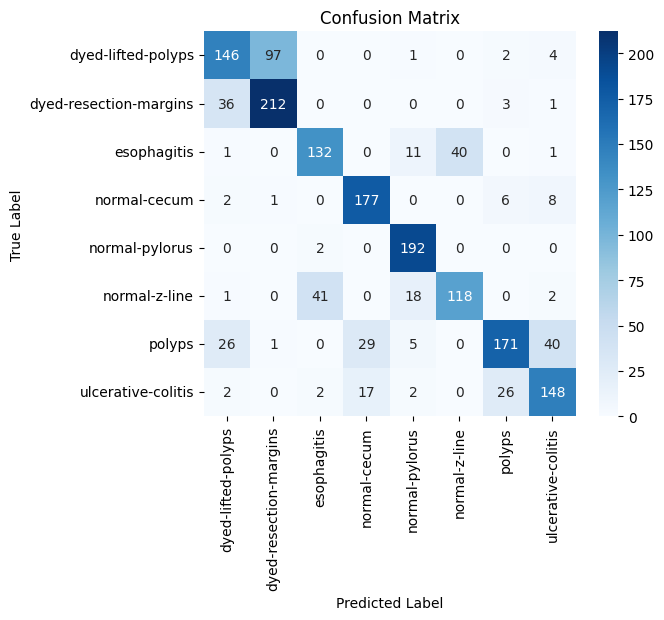

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

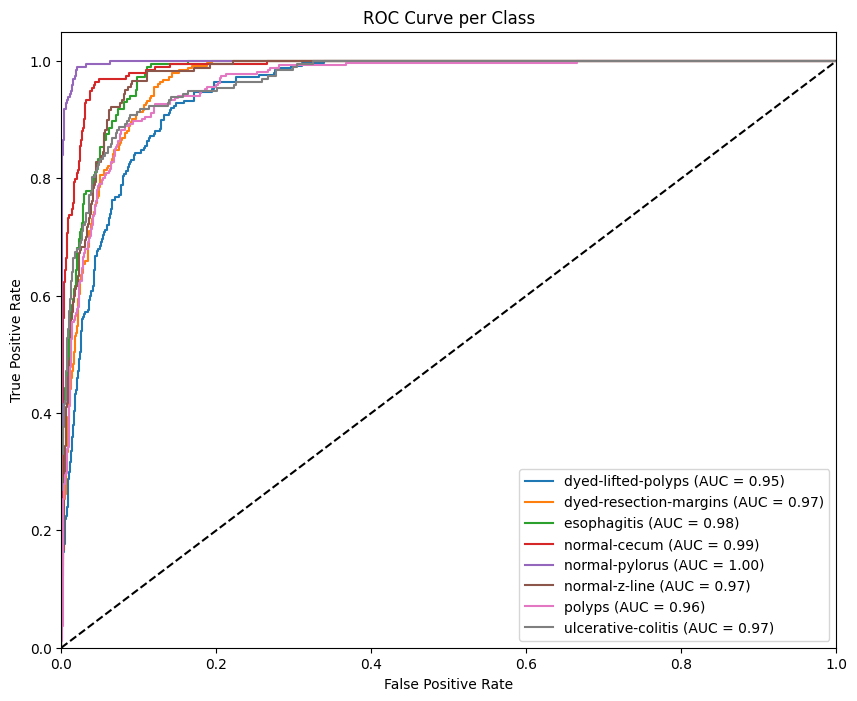

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get class names from the test_generator
class_names = list(test_generator.class_indices.keys())

# One-hot encoding للـ labels
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
n_classes = y_true_bin.shape[1]

plt.figure(figsize=(10,8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_pred[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')  # خط الRandom
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Class')
plt.legend(loc='lower right')
plt.show()

In [ ]:
import cv2
import numpy as np
from tensorflow.keras.applications.resnet_v2 import preprocess_input


def load_and_preprocess_image(img_path, target_size=(224,224)):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("الصورة مش موجودة أو المسار غلط")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    img = np.expand_dims(img, axis=0)  # إضافة batch dimension
    img = preprocess_input(img)  # لازم زي ما عملنا في الـ train
    return img

img_path = '/content/drive/MyDrive/dataset_splitR/test/ulcerative-colitis/06e4732b-9335-4c5a-a1af-17833b81905d.jpg'  # حطي مسار صورتك هنا
img = load_and_preprocess_image(img_path)

pred_prob = model.predict(img)  # probability لكل كلاس
pred_class = np.argmax(pred_prob, axis=1)[0]  # index للكلاس المتوقع


class_labels = list(train_generator.class_indices.keys())  # أسماء الكلاسات
print(f"الصورة تنتمي لكلاس: {class_labels[pred_class]}")
print(f"احتمالية كل كلاس: {pred_prob}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
الصورة تنتمي لكلاس: polyps
احتمالية كل كلاس: [[2.4440663e-11 1.8042760e-24 2.3128564e-19 5.2161518e-22 9.1266006e-10
  2.6135511e-12 9.9999964e-01 3.7532931e-07]]
